In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)


In [2]:
file_path = "../data/online_retail_II.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 525461
Columns: 8


In [3]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


In [7]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [8]:
excel_file = pd.ExcelFile("../data/online_retail_II.xlsx")

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [9]:
sheet1 = pd.read_excel(
    "../data/online_retail_II.xlsx",
    sheet_name=0
)

sheet2 = pd.read_excel(
    "../data/online_retail_II.xlsx",
    sheet_name=1
)

df = pd.concat([sheet1, sheet2], ignore_index=True)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1067371
Columns: 8


In [10]:
# Make a copy before cleaning
df_clean = df.copy()

print("Original rows:", len(df_clean))

# 1. Remove duplicate transactions
df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", len(df_clean))

# 2. Remove transactions without Customer ID
df_clean = df_clean.dropna(subset=["Customer ID"])

print("After removing missing Customer IDs:", len(df_clean))

# 3. Remove cancelled invoices
# Cancelled invoices have invoice numbers beginning with 'C'
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

print("After removing cancelled invoices:", len(df_clean))

# 4. Remove invalid quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# 5. Remove invalid prices
df_clean = df_clean[df_clean["Price"] > 0]

print("After removing invalid quantities/prices:", len(df_clean))

Original rows: 1067371
After removing duplicates: 1033036
After removing missing Customer IDs: 797885
After removing cancelled invoices: 779495
After removing invalid quantities/prices: 779425


In [11]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
print(df_clean.shape)

(779425, 8)


In [13]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

df_clean[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [14]:
df_clean["Revenue"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [15]:
print(f"Total Revenue: £{df_clean['Revenue'].sum():,.2f}")

Total Revenue: £17,374,804.27


In [16]:
print("Start Date:", df_clean["InvoiceDate"].min())
print("End Date:", df_clean["InvoiceDate"].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [17]:
print("Unique Customers:", df_clean["Customer ID"].nunique())
print("Unique Products:", df_clean["StockCode"].nunique())
print("Unique Countries:", df_clean["Country"].nunique())

Unique Customers: 5878
Unique Products: 4631
Unique Countries: 41


In [18]:
# Monthly revenue trend
# Extract year-month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df_clean.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

monthly_revenue.head()

,YearMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


Matplotlib is building the font cache; this may take a moment.


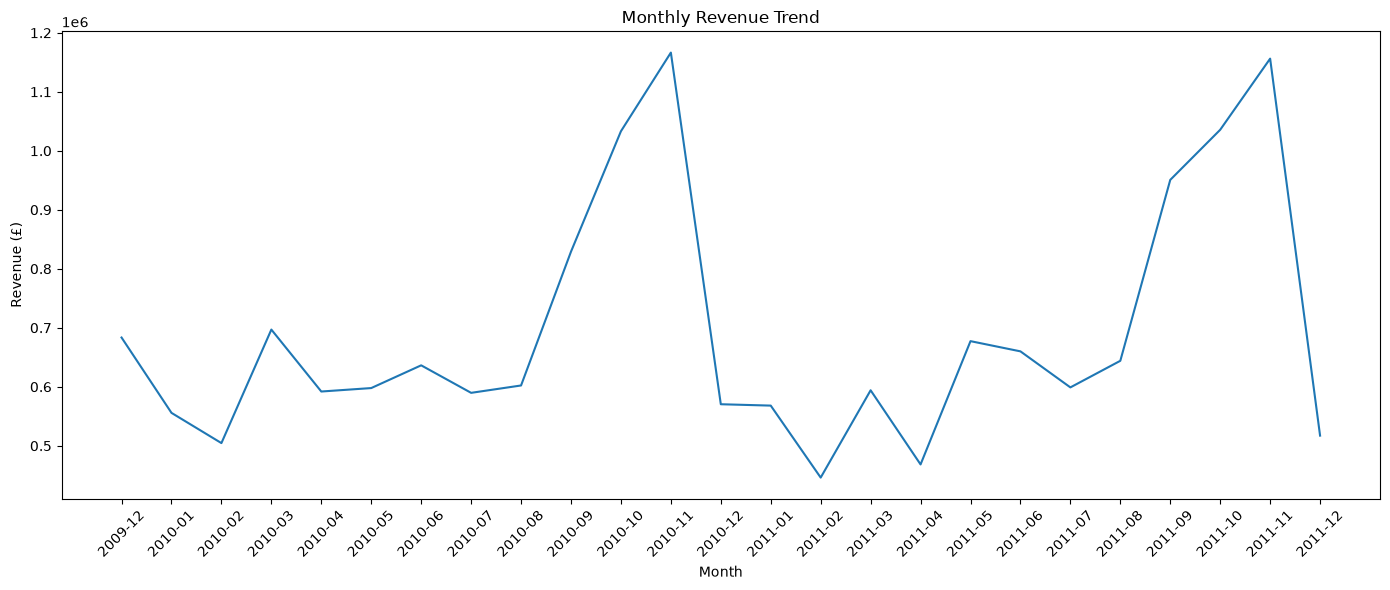

In [ ]:
#Top 10 countries by revenue
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Revenue"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

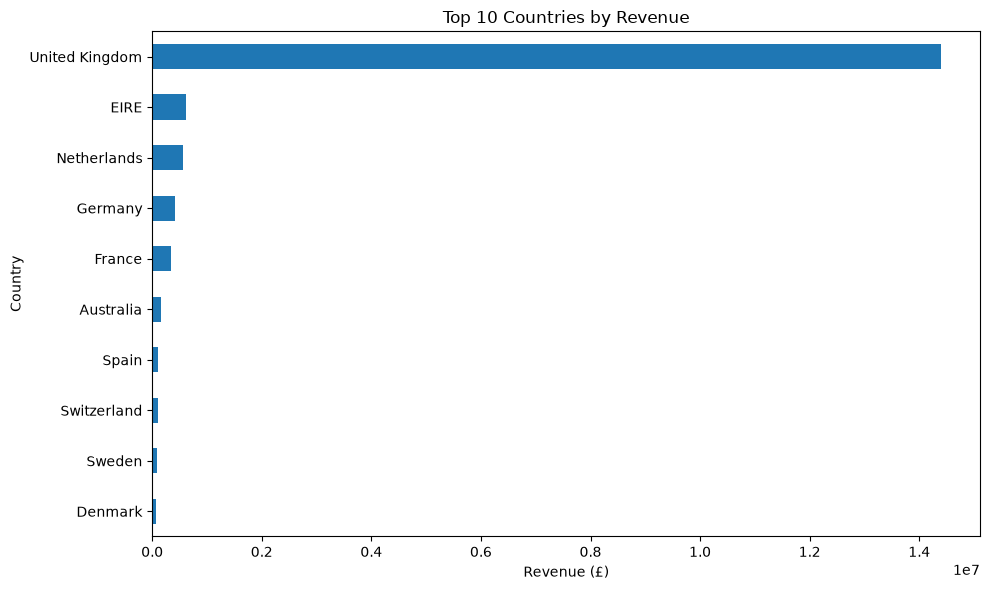

In [21]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [ ]:
#Top 10 products by revenue
product_revenue = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

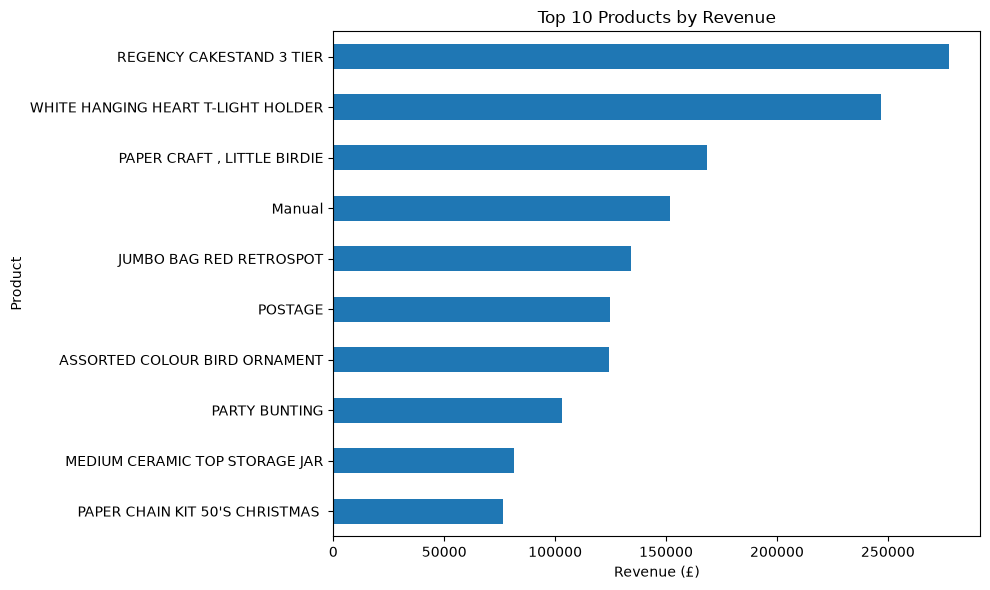

In [23]:
plt.figure(figsize=(10, 6))

product_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [25]:
#Customer purchasing behavior
customer_summary = (
    df_clean.groupby("Customer ID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Invoice", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique")
    )
    .reset_index()
)

customer_summary.head()

,Customer ID,Total_Revenue,Total_Orders,Total_Quantity,Unique_Products
0,12346.0,77556.46,12,74285,27
1,12347.0,4921.53,8,2967,126
2,12348.0,2019.40,5,2714,25
3,12349.0,4428.69,4,1624,138
4,12350.0,334.40,1,197,17


In [26]:
customer_summary.describe()

,Customer ID,Total_Revenue,Total_Orders,Total_Quantity,Unique_Products
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,2955.904095,6.289384,1788.695475,81.989112
std,1715.572666,14440.852688,13.009406,8876.297196,116.484552
min,12346.000000,2.950000,1.000000,1.000000,1.000000
25%,13833.250000,342.280000,1.000000,187.000000,19.000000
50%,15314.500000,867.740000,3.000000,480.000000,45.000000
75%,16797.750000,2248.305000,7.000000,1350.000000,103.000000
max,18287.000000,580987.040000,398.000000,367193.000000,2550.000000


In [28]:
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,Customer ID,Total_Revenue,Total_Orders,Total_Quantity,Unique_Products
5692,18102.0,580987.04,145,181645,382
2277,14646.0,528602.52,151,367193,961
1789,14156.0,313437.62,156,164325,1446
2538,14911.0,291420.81,398,147972,2550
5050,17450.0,244784.25,51,83914,144
1331,13694.0,195640.69,143,188201,896
5109,17511.0,172132.87,60,117174,657
4061,16446.0,168472.50,2,80997,3
4295,16684.0,147142.77,55,104810,184
68,12415.0,144458.37,28,91447,498


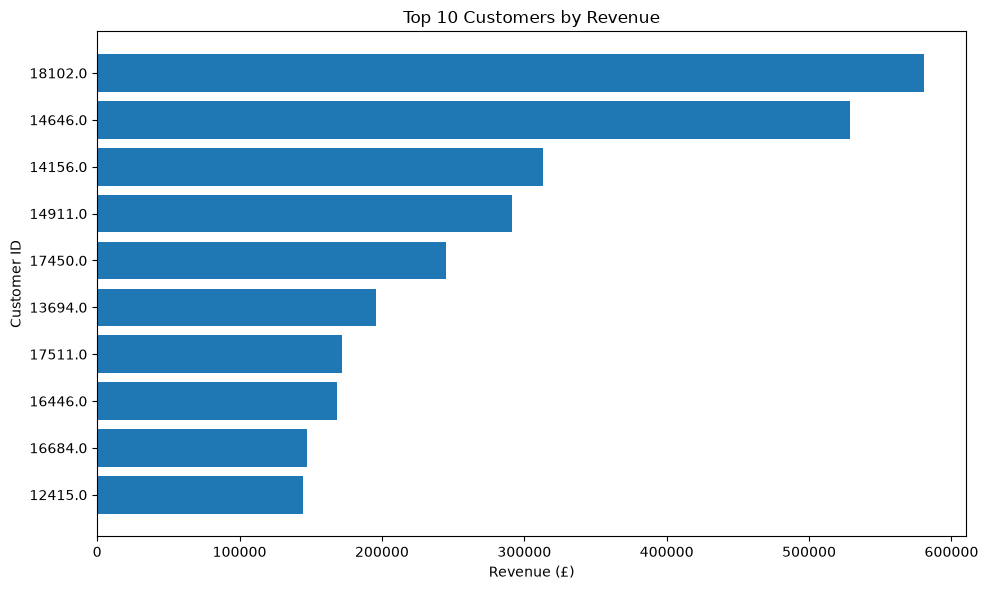

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["Customer ID"].astype(str),
    top_customers["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
#RFM Analysis
#RFM means:

# Recency → How recently did the customer purchase?
# Frequency → How often did they purchase?
# Monetary → How much did they spend?

In [30]:
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [31]:
rfm = (
    df_clean.groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [32]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


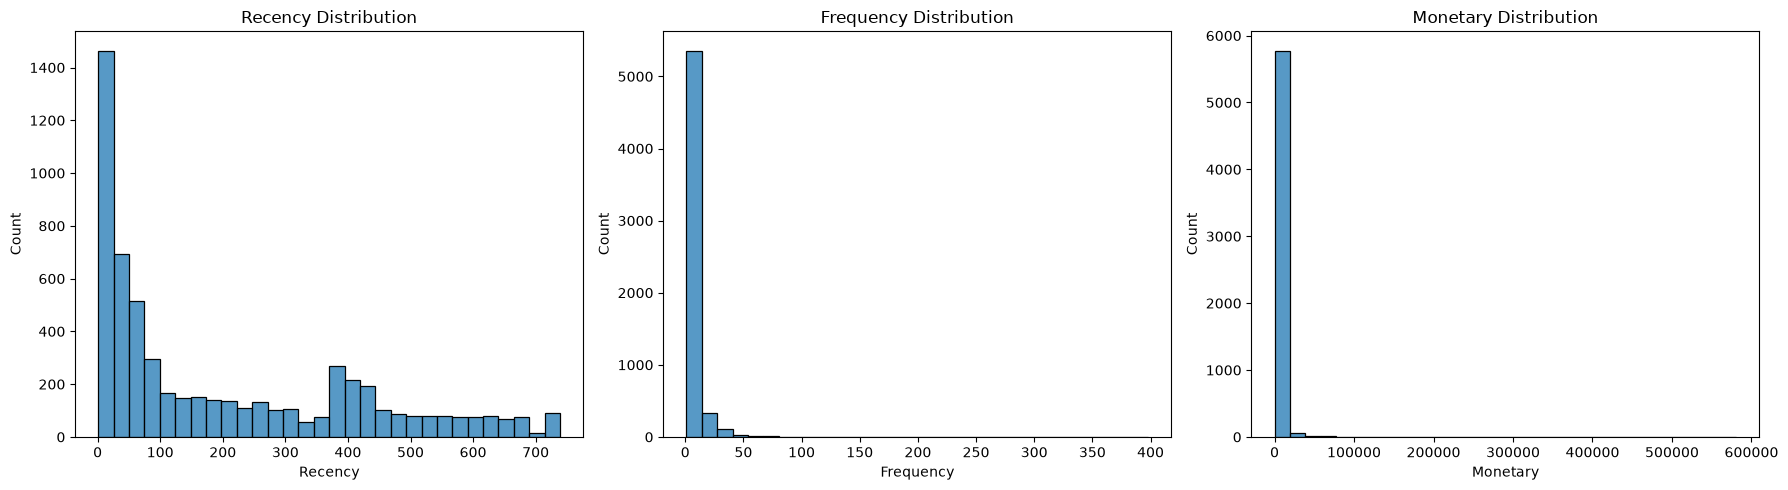

In [33]:
#Prepare RFM for Machine Learning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [34]:
#Transform RFM
rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Log transformation to reduce skewness
rfm_log = np.log1p(rfm_features)

rfm_log.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.816979
std,1.559404,0.809447,1.385486
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.838546
50%,4.574711,1.386294,6.767044
75%,5.942799,2.079442,7.718377
max,6.606650,5.988961,13.272485


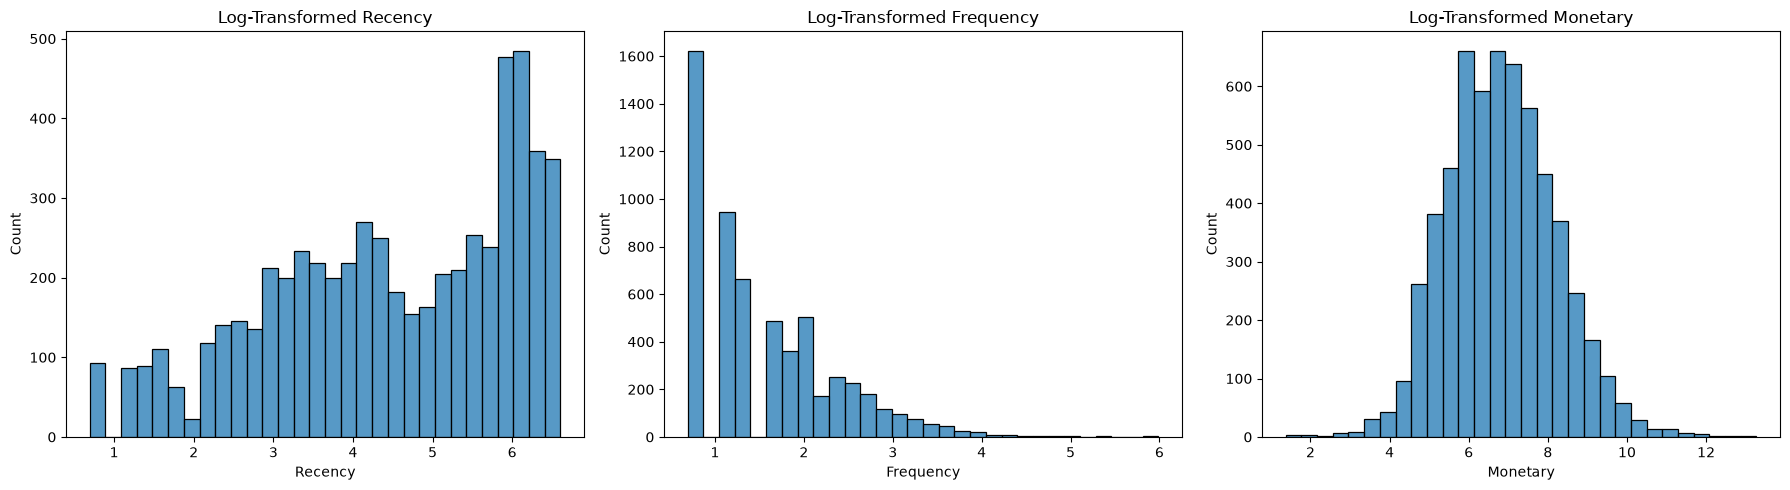

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_log["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Log-Transformed Recency")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Log-Transformed Frequency")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Log-Transformed Monetary")

plt.tight_layout()
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.856701,1.254496,3.206219
1,-2.151979,0.800166,1.215993
2,-0.079138,0.299207,0.573185
3,-0.935308,0.073946,1.139846
4,0.824527,-1.058146,-0.723024


In [37]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,-5.052856e-16,2.381370e-16,3.771510e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.412014e+00,-1.058146e+00,-3.929108e+00
25%,-7.428435e-01,-1.058146e+00,-7.062613e-01
50%,7.733065e-02,-2.017514e-01,-3.604460e-02
75%,9.547202e-01,6.546432e-01,6.506556e-01
max,1.380464e+00,5.484918e+00,4.659776e+00


In [39]:
# Find the optimal number of clusters
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

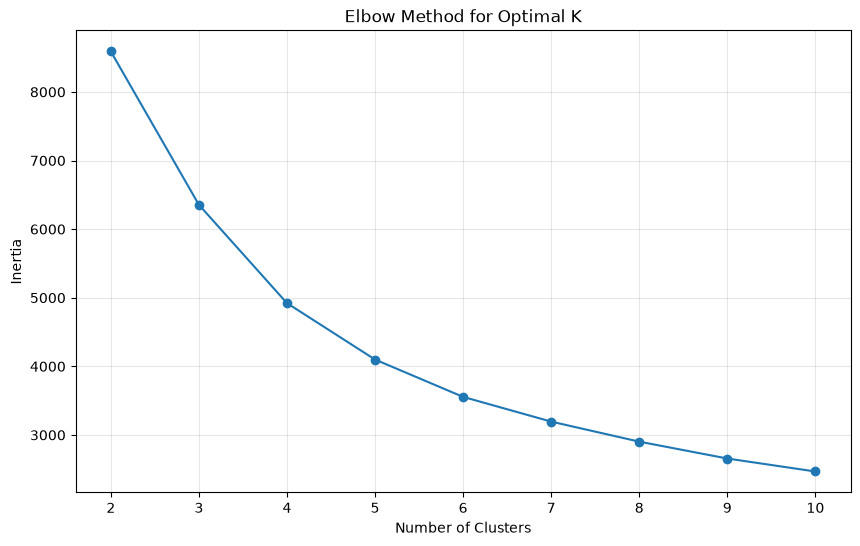

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)

plt.show()


In [41]:
#Build 5 customer segments
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,2
1,12347.0,2,8,4921.53,2
2,12348.0,75,5,2019.40,2
3,12349.0,19,4,4428.69,2
4,12350.0,310,1,334.40,4


In [42]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Cluster
0     458
1    1363
2    1294
3    1143
4    1620
Name: count, dtype: int64


In [43]:
#Profile the segments
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,458,18.06,32.90,20817.59
1,1363,293.71,3.80,1385.85
2,1294,48.87,9.13,3673.51
3,1143,32.46,2.53,682.55
4,1620,416.35,1.25,257.87


In [44]:
#sort by customer value
cluster_profile.sort_values(
    "Avg_Monetary",
    ascending=False
)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,458,18.06,32.90,20817.59
2,1294,48.87,9.13,3673.51
1,1363,293.71,3.80,1385.85
3,1143,32.46,2.53,682.55
4,1620,416.35,1.25,257.87


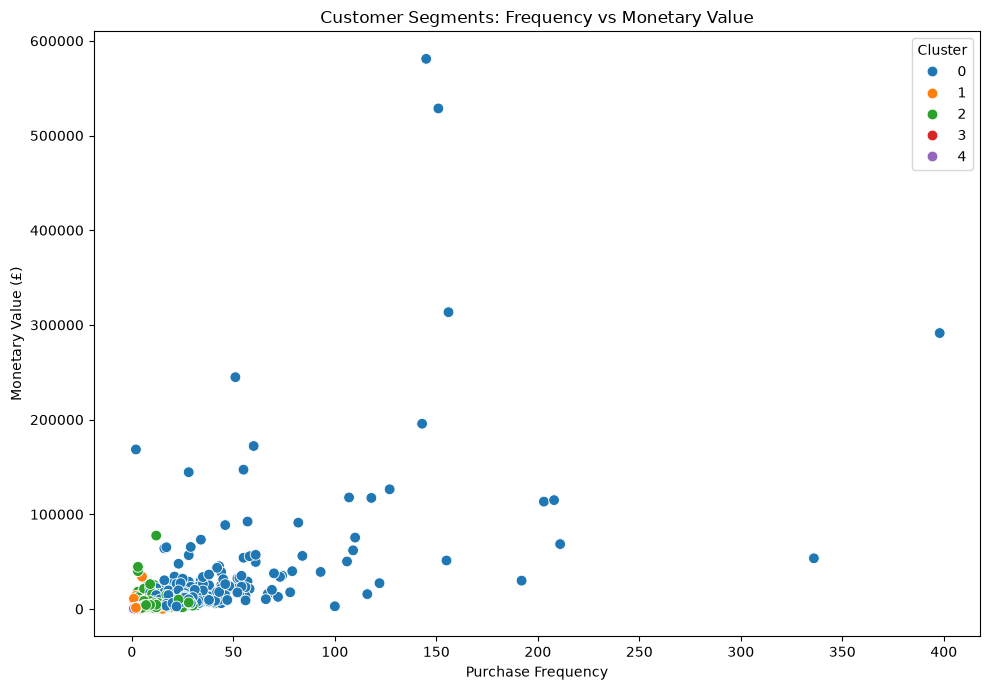

In [45]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value (£)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [47]:
#Adding readable segment names
cluster_profile.sort_values("Avg_Monetary", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,458,18.06,32.90,20817.59
2,1294,48.87,9.13,3673.51
1,1363,293.71,3.80,1385.85
3,1143,32.46,2.53,682.55
4,1620,416.35,1.25,257.87


In [48]:
#total revenue by cluster
cluster_revenue = (
    rfm.groupby("Cluster")["Monetary"]
    .agg(["sum", "mean", "count"])
    .round(2)
)

cluster_revenue["Revenue_Share_%"] = (
    cluster_revenue["sum"] / rfm["Monetary"].sum() * 100
).round(2)

cluster_revenue.sort_values("sum", ascending=False)

,sum,mean,count,Revenue_Share_%
Cluster,,,,
0,9534456.88,20817.59,458,54.88
2,4753522.54,3673.51,1294,27.36
1,1888917.71,1385.85,1363,10.87
3,780150.98,682.55,1143,4.49
4,417756.15,257.87,1620,2.40


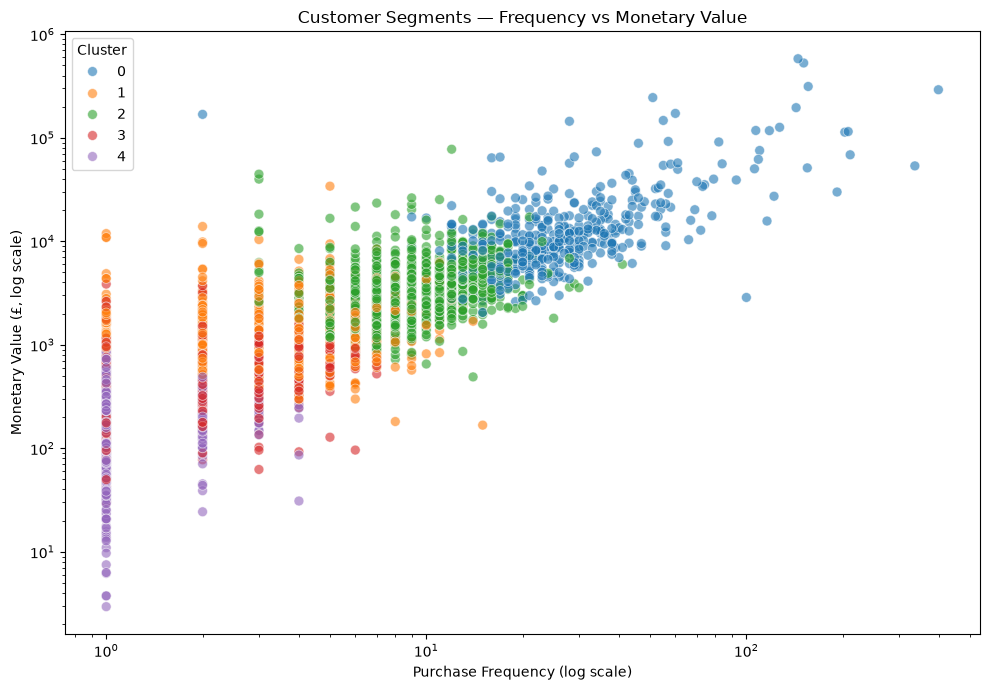

In [49]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    s=50,
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Customer Segments — Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency (log scale)")
plt.ylabel("Monetary Value (£, log scale)")

plt.tight_layout()
plt.show()

In [50]:
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile.sort_values("Avg_Monetary", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,458,18.06,32.90,20817.59
2,1294,48.87,9.13,3673.51
1,1363,293.71,3.80,1385.85
3,1143,32.46,2.53,682.55
4,1620,416.35,1.25,257.87


In [51]:
cluster_revenue = (
    rfm.groupby("Cluster")["Monetary"]
    .agg(
        Total_Revenue="sum",
        Avg_Revenue="mean",
        Customers="count"
    )
)

cluster_revenue["Revenue_Share_%"] = (
    cluster_revenue["Total_Revenue"]
    / rfm["Monetary"].sum()
    * 100
).round(2)

cluster_revenue.sort_values("Total_Revenue", ascending=False)

,Total_Revenue,Avg_Revenue,Customers,Revenue_Share_%
Cluster,,,,
0,9534456.884,20817.591450,458,54.88
2,4753522.538,3673.510462,1294,27.36
1,1888917.713,1385.853054,1363,10.87
3,780150.982,682.546791,1143,4.49
4,417756.151,257.874167,1620,2.40


In [52]:
cluster_names = {
    0: "High-Value Loyal",
    1: "At Risk",
    2: "Loyal / Growing",
    3: "Recent / Occasional",
    4: "Inactive"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm[["Customer ID", "Recency", "Frequency", "Monetary", "Segment"]].head()

,Customer ID,Recency,Frequency,Monetary,Segment
0,12346.0,326,12,77556.46,Loyal / Growing
1,12347.0,2,8,4921.53,Loyal / Growing
2,12348.0,75,5,2019.40,Loyal / Growing
3,12349.0,19,4,4428.69,Loyal / Growing
4,12350.0,310,1,334.40,Inactive


In [53]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .round(2)
)

segment_summary.sort_values("Total_Revenue", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
High-Value Loyal,458,18.06,32.90,20817.59,9534456.88
Loyal / Growing,1294,48.87,9.13,3673.51,4753522.54
At Risk,1363,293.71,3.80,1385.85,1888917.71
Recent / Occasional,1143,32.46,2.53,682.55,780150.98
Inactive,1620,416.35,1.25,257.87,417756.15


## Customer Segment Strategy

### High-Value Loyal
- Protect and retain these customers.
- Offer VIP benefits and early access.
- Avoid unnecessary discounts because these customers already generate high value.

### Loyal / Growing
- Encourage higher purchase frequency.
- Cross-sell complementary products.
- Use personalized recommendations.

### At Risk
- Target customers who have previously generated meaningful revenue.
- Use reactivation campaigns and personalized offers.
- Prioritize this segment because recovering existing customers can be cheaper than acquiring new ones.

### Recent / Occasional
- Improve onboarding and encourage a second purchase.
- Recommend related products based on their first purchases.

### Inactive
- Use low-cost reactivation campaigns.
- Test whether incentives can bring them back.
- Avoid spending heavily if reactivation rates remain low.

In [57]:
# Code cell
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,12,77556.46,2,Loyal / Growing
1,12347.0,2,8,4921.53,2,Loyal / Growing
2,12348.0,75,5,2019.40,2,Loyal / Growing
3,12349.0,19,4,4428.69,2,Loyal / Growing
4,12350.0,310,1,334.40,4,Inactive


## Customer Segment Strategy

Our highest-value customers contribute a disproportionate
share of total revenue.

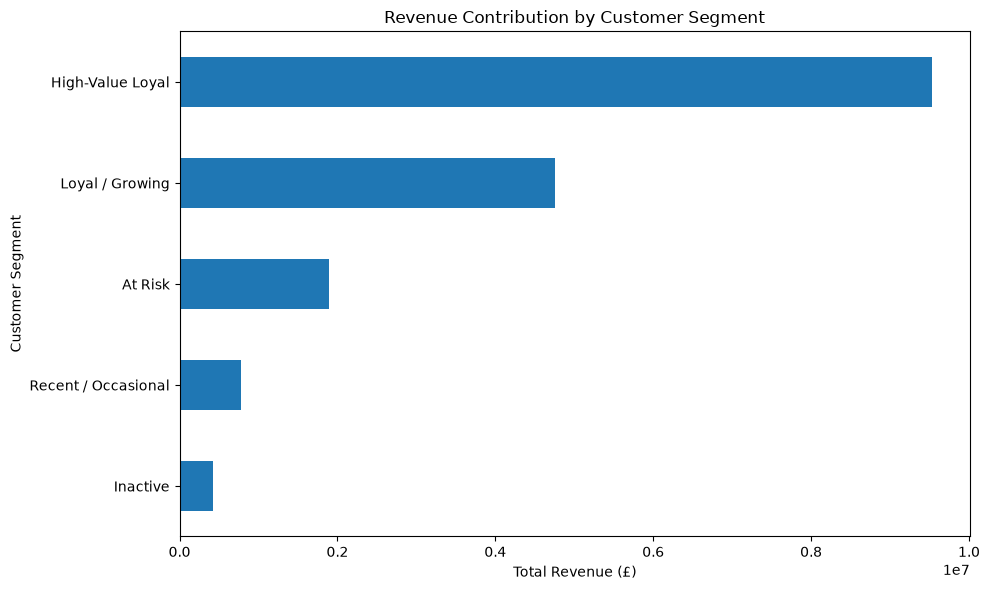

In [58]:
#Revenue contribution by segment
plt.figure(figsize=(10, 6))

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=True)
)

segment_revenue.plot(kind="barh")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

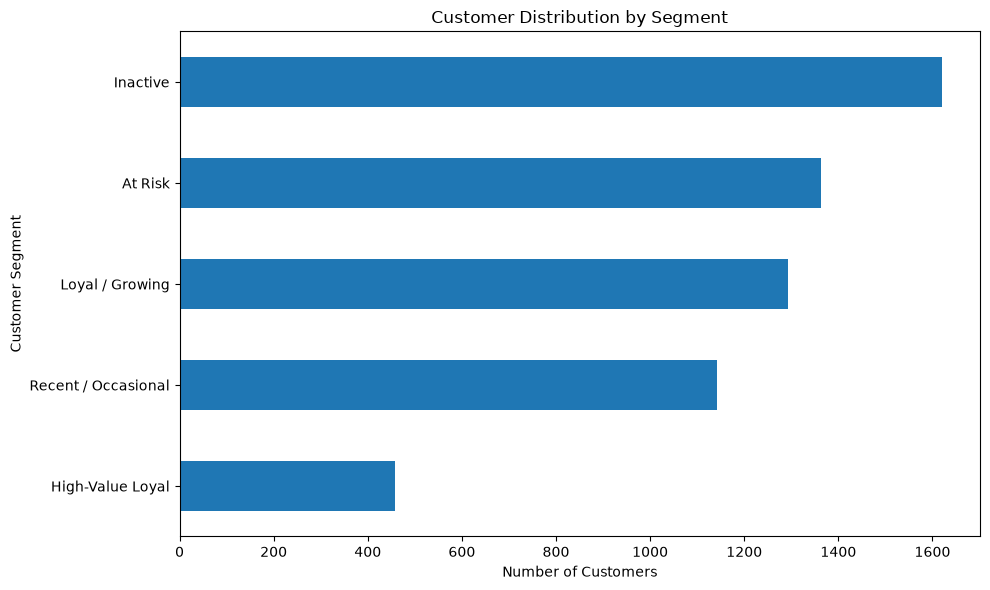

In [59]:
#Customer distribution
plt.figure(figsize=(10, 6))

segment_customers = (
    rfm["Segment"]
    .value_counts()
    .sort_values(ascending=True)
)

segment_customers.plot(kind="barh")

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

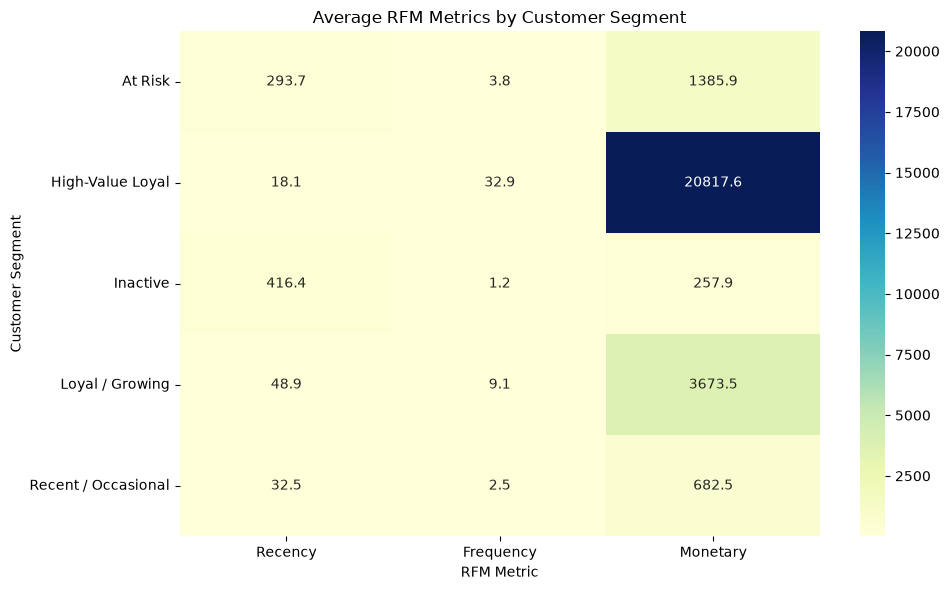

In [60]:
#RFM segment heatmap
heatmap_data = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average RFM Metrics by Customer Segment")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [61]:
# Save the customer segmentation dataset
rfm.to_csv(
    "../reports/customer_segments.csv",
    index=False
)

print("Customer segmentation saved successfully!")

Customer segmentation saved successfully!
